In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Penelitian_@/data/"

data_twitter_rupiah_melemah.xlsx  gabungan_all_tweets.csv


In [ ]:
!pip install nltk Sastrawi pandas wordcloud tqdm emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 6.9 MB/s eta 0:00:00


In [ ]:
# =========================================================
# CEK 5 BARIS AWAL & 5 BARIS AKHIR
# =========================================================

import pandas as pd

# Load file
file_path = '/content/drive/MyDrive/Penelitian_@/data/data_twitter_rupiah_melemah.xlsx'
df = pd.read_excel(file_path)

print("="*80)
print("📊 VERIFIKASI DATA TWITTER")
print("="*80)

print(f"\n✅ Total data: {len(df):,} rows")
print(f"✅ Total kolom: {len(df.columns)} columns")

# =========================================================
# CEK 5 BARIS PERTAMA
# =========================================================
print("\n" + "="*80)
print("📝 5 BARIS PERTAMA (AWAL DATA)")
print("="*80)

for i in range(min(5, len(df))):
    print(f"\n--- ROW {i+1} ---")
    print(f"Twitter URL: {df['twitterUrl'].iloc[i]}")
    print(f"Tanggal: {df['createdAt'].iloc[i]}")
    print(f"Username: {df['author'].iloc[i]['userName'] if isinstance(df['author'].iloc[i], dict) else df['author'].iloc[i]}")
    print(f"Text: {df['text'].iloc[i][:200]}...")
    print(f"Retweet: {df['retweetCount'].iloc[i]}, Like: {df['likeCount'].iloc[i]}, Reply: {df['replyCount'].iloc[i]}")
    print("-" * 60)

# =========================================================
# CEK 5 BARIS TERAKHIR
# =========================================================
print("\n" + "="*80)
print("📝 5 BARIS TERAKHIR (AKHIR DATA)")
print("="*80)

for i in range(len(df)-5, len(df)):
    print(f"\n--- ROW {i+1} ---")
    print(f"Twitter URL: {df['twitterUrl'].iloc[i]}")
    print(f"Tanggal: {df['createdAt'].iloc[i]}")
    print(f"Username: {df['author'].iloc[i]['userName'] if isinstance(df['author'].iloc[i], dict) else df['author'].iloc[i]}")
    print(f"Text: {df['text'].iloc[i][:200]}...")
    print(f"Retweet: {df['retweetCount'].iloc[i]}, Like: {df['likeCount'].iloc[i]}, Reply: {df['replyCount'].iloc[i]}")
    print("-" * 60)

# =========================================================
# STATISTIK RINGKAS
# =========================================================
print("\n" + "="*80)
print("📊 STATISTIK RINGKAS")
print("="*80)

# Rentang waktu
from datetime import datetime
created_dates = pd.to_datetime(df['createdAt'])
print(f"\n📅 Rentang Waktu:")
print(f"   - Pertama: {created_dates.min()}")
print(f"   - Terakhir: {created_dates.max()}")
print(f"   - Durasi: {(created_dates.max() - created_dates.min()).days} hari")

# Statistik interaksi
print(f"\n💬 Statistik Interaksi:")
print(f"   - Total Retweet: {df['retweetCount'].sum():,}")
print(f"   - Total Like: {df['likeCount'].sum():,}")
print(f"   - Total Reply: {df['replyCount'].sum():,}")
print(f"   - Total Quote: {df['quoteCount'].sum():,}")
print(f"   - Total View: {df['viewCount'].sum():,}")

# Bahasa
print(f"\n🌐 Bahasa:")
print(df['lang'].value_counts().head(10))

# Username populer (if author is dict)
print(f"\n👤 Top 10 Username (berdasarkan jumlah tweet):")
# Extract username from author dict
author_names = []
for author in df['author']:
    if isinstance(author, dict) and 'userName' in author:
        author_names.append(author['userName'])
    else:
        author_names.append(str(author))

from collections import Counter
top_users = Counter(author_names).most_common(10)
for user, count in top_users:
    print(f"   - @{user}: {count} tweets")

print("\n" + "="*80)
print("✅ VERIFIKASI SELESAI!")
print("="*80)

📊 VERIFIKASI DATA TWITTER

✅ Total data: 15,000 rows
✅ Total kolom: 32 columns

📝 5 BARIS PERTAMA (AWAL DATA)

--- ROW 1 ---
Twitter URL: https://twitter.com/DeancasterFx/status/2053397280322142469
Tanggal: Sun May 10 08:50:36 +0000 2026
Username: {'type': 'user', 'userName': 'DeancasterFx', 'url': 'https://x.com/DeancasterFx', 'twitterUrl': 'https://twitter.com/DeancasterFx', 'id': '2053370459677429760', 'name': 'Deancaster | IHSG & Bitcoin', 'isVerified': False, 'isBlueVerified': False, 'profilePicture': 'https://pbs.twimg.com/profile_images/2053372804146540544/I9vN5c8c_normal.jpg', 'coverPicture': 'https://pbs.twimg.com/profile_banners/2053370459677429760/1778397223', 'description': 'leven zonder monteurs', 'location': '', 'followers': 0, 'following': 50, 'status': '', 'canDm': False, 'canMediaTag': False, 'createdAt': 'Sun May 10 07:05:10 +0000 2026', 'entities': {'description': {'urls': []}, 'url': {}}, 'fastFollowersCount': 0, 'favouritesCount': 4, 'hasCustomTimelines': True, 'is

/tmp/ipykernel_10262/596785049.py:59: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  created_dates = pd.to_datetime(df['createdAt'])



📅 Rentang Waktu:
   - Pertama: 2026-05-03 23:19:16+00:00
   - Terakhir: 2026-05-10 08:50:36+00:00
   - Durasi: 6 hari

💬 Statistik Interaksi:
   - Total Retweet: 131,127
   - Total Like: 582,580
   - Total Reply: 25,363
   - Total Quote: 15,554
   - Total View: 35,432,765

🌐 Bahasa:
lang
in     14407
en       563
ko         5
und        4
eu         3
de         3
qme        3
es         2
nl         2
tl         2
Name: count, dtype: int64

👤 Top 10 Username (berdasarkan jumlah tweet):
   - @{'type': 'user', 'userName': 'Kinkin18051341', 'url': 'https://x.com/Kinkin18051341', 'twitterUrl': 'https://twitter.com/Kinkin18051341', 'id': '1010967580419358720', 'name': 'Kinkin', 'isVerified': False, 'isBlueVerified': False, 'profilePicture': 'https://pbs.twimg.com/profile_images/2052556044052897792/lsbu9YE1_normal.jpg', 'coverPicture': 'https://pbs.twimg.com/profile_banners/1010967580419358720/1757148004', 'description': 'di folback', 'location': 'Bandung, Indonesia', 'followers': 143, 'fo

In [ ]:
import os
import pickle

# Hapus cache lama
cache_file = '/content/drive/MyDrive/Penelitian_@/progress/stem_cache.pkl'
if os.path.exists(cache_file):
    os.remove(cache_file)
    print("✅ Cache lama telah dihapus!")

# Hapus juga checkpoint agar proses dari awal
checkpoint_file = '/content/drive/MyDrive/Penelitian_@/progress/checkpoint.csv'
if os.path.exists(checkpoint_file):
    os.remove(checkpoint_file)
    print("✅ Checkpoint lama telah dihapus!")

print("Sekarang jalankan ulang preprocessing!")

✅ Cache lama telah dihapus!
✅ Checkpoint lama telah dihapus!
Sekarang jalankan ulang preprocessing!


In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import os
import re
import pickle
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer

# =========================================================
# DOWNLOAD NLTK
# =========================================================
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# =========================================================
# KONFIGURASI
# =========================================================
class Config:
    PROGRESS_DIR = '/content/drive/MyDrive/Penelitian_@/progress'
    CACHE_FILE = os.path.join(PROGRESS_DIR, 'stem_cache.pkl')
    CHECKPOINT_FILE = os.path.join(PROGRESS_DIR, 'checkpoint.csv')
    FINAL_OUTPUT = os.path.join(PROGRESS_DIR, 'hasil_preprocessing_final.csv')
    VOCAB_OUTPUT = os.path.join(PROGRESS_DIR, 'top_vocabulary.csv')
    PIPELINE_LOG = os.path.join(PROGRESS_DIR, 'pipeline_log.csv')

os.makedirs(Config.PROGRESS_DIR, exist_ok=True)

# =========================================================
# TOKENIZER
# =========================================================
tokenizer = TweetTokenizer()

# =========================================================
# SLANG MAPPING (DIPERBESAR UNTUK TWITTER)
# =========================================================
slang_dict = {
    "sampe": "sampai", "smpai": "sampai",
    "tau": "tahu","taU": "tahu",
    # Negasi
    "belom": "belum", "blom": "belum", "blm": "belum",
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "kagak": "tidak",
    "gx": "tidak", "gd": "tidak", "tdk": "tidak",
    # Kata hubung
    "yg": "yang", "dgn": "dengan", "dr": "dari", "krn": "karena",
    "aja": "saja", "udh": "sudah", "sm": "sama", "klo": "kalau",
    "trs": "terus", "bgt": "banget", "dlm": "dalam",
    # Kata tanya
    "gmn": "bagaimana", "knp": "kenapa", "org": "orang", "sy": "saya",
    "gimana": "bagaimana", "gini": "seperti_ini", "gitu": "seperti_itu",
    "bgtu": "begitu", "emang": "memang", "kayak": "seperti",
    # Partikel
    "cuma": "hanya", "doang": "saja", "nih": "ini", "sih": "saja",
    "dong": "lah", "kan": "karena", "kok": "mengapa", "ya": "iya",
    "yah": "iya", "sih": "saja", "dah": "sudah", "deh": "sudah",
    "tuh": "itu", "kek": "seperti", "emg": "memang", "si": "seseorang",
    "kali": "kalau",
    # Satuan
    "rb": "ribu", "jt": "juta", "m": "miliar", "t": "triliun",
    "usd": "dolar", "idr": "rupiah", "bbm": "bahan_bakar_minyak",
    # Ekspresi
    "wkwk": "tertawa", "wkwkwk": "tertawa", "haha": "tertawa",
    "hehe": "tertawa", "xixi": "tertawa", "lol": "tertawa",
    "skrng": "sekarang", "skrg": "sekarang", "skr": "sekarang",
    "skarang": "sekarang",
}

# =========================================================
# KATA PENTING YANG TIDAK BOLEH DI-STEM ATAU DIHAPUS
# =========================================================
important_words = {
    # Ekonomi
    'rupiah', 'dolar', 'dollar', 'kurs', 'inflasi', 'ekonomi',
    'bank', 'pasar', 'harga', 'investasi', 'saham', 'ihsg',
    'apbn', 'defisit', 'minyak', 'cadangan_devisa', 'biaya',
    # Perubahan
    'naik', 'turun', 'melemah', 'menguat', 'anjlok', 'meroket',
    'melonjak', 'merosot', 'stabil', 'terpuruk', 'krisis',
    # Akronim penting
    'mbg', 'wni', 'apbn', 'ihsg', 'bps', 'bi', 'pmi',
    # Negasi (PENTING untuk sentimen!)
    'tidak', 'bukan', 'jangan', 'belum', 'masih', 'sudah', 'pernah',
    # Verba penting
    'bisa', 'dapat', 'harus', 'ingin', 'butuh', 'punya', 'perlu',
    # Waktu
    'hari', 'bulan', 'tahun', 'kemarin', 'hari_ini', 'besok',
}

# =========================================================
# KATA YANG TIDAK BOLEH DI-STEMMING (PERTAHANKAN BENTUK ASLI)
# =========================================================
preserve_words = {
    'sampai', 'sampai',
    'kebutuhan', 'kebutuhan',
    'keuangan', 'keuangan',
    'jangan', 'negeri', 'negara', 'beli', 'belanja', 'belajar', 'belakang',
    'rakyat', 'masyarakat', 'warga', 'bangsa',
    'strategi', 'strategis', 'kondisi', 'situasi', 'keadaan', 'kejadian',
    'menangis', 'menang', 'sebab', 'kenapa', 'mengapa', 'karena',
    'emoji_menangis', 'emoji_sedih', 'emoji_ketawa', 'emoji_marah',
    'naik', 'turun', 'melemah', 'menguat', 'anjlok', 'meroket',
    'merosot', 'melambung', 'terjun', 'tenggelam', 'melorot',
    'meningkat', 'menurun', 'melonjak', 'berkurang', 'bertambah',
    'tertinggi', 'terendah', 'terparah', 'terbaik', 'terburuk',
    'senang', 'sedih', 'marah', 'kecewa', 'khawatir', 'panik',
    'harapan', 'kenyataan', 'fakta', 'data', 'informasi',
    'pertumbuhan', 'ekonomi', 'pemerintah', 'presiden', 'menteri',
    # Tambahan dari hasil debug
    'mbg', 'pas', 'tau', 'jam', 'kal', 'fee', 'cek', 'pakai', 'buat',
    'karana', 'karna', 'sebab', 'biar', 'agar', 'supaya', 'walau', 'meski',
    'kebijakan', 'kebijakan','kenaikan', 'kenaikan', 'penguatan', 'penguatan',
    'memperkuat', 'memperkuat', 'sekarang', 'sekarang', 'seperti', 'seperti',
    'subsidi', 'subsidi', 'kekuatan', 'kekuatan', 'kuat', 'kuat', 'kalau', 'kalau',  # cegah 'kali' dari 'kalau'
}

# =========================================================
# CUSTOM STEMMER (MINIMALIS & TIDAK AGRESIF)
# =========================================================
def custom_stem(word):
    # 1. Kalau kata pendek (<5 huruf), langsung kembalikan (jangan distem!)
    if len(word) <= 5:
        return word

    # 2. Kalau di preserve_words, jangan di-stem
    if word in preserve_words:
        return word

    # 3. STEM HANYA UNTUK KATA PANJANG (>6 huruf) DAN IMBUHAN JELAS
    # Aturan -kan (paling aman)
    if word.endswith('kan') and len(word) >= 7:
        stem = word[:-3]
        if len(stem) >= 4 and stem not in preserve_words:
            return stem

    # Aturan -an (hanya untuk kata panjang >7)
    if word.endswith('an') and len(word) >= 7 and word not in ['jangan', 'tangan', 'kawan', ' sekitaran', 'cuman']:
        stem = word[:-2]
        if len(stem) >= 5 and stem not in preserve_words:
            return stem

    # Aturan -i (hanya untuk kata panjang >6)
    if word.endswith('i') and len(word) >= 6 and word[-2] not in 'aiueo':
        stem = word[:-1]
        if len(stem) >= 5 and stem not in preserve_words:
            return stem

    # 4. AWALAN (hanya untuk kata yang masih panjang setelah dihilangkan)
    if word.startswith('memper') and len(word) >= 8:
        without_memper = word[5:]
        if len(without_memper) >= 4 and without_memper in preserve_words:
            return without_memper

    if word.startswith('ber') and len(word) >= 6:
        without_ber = word[3:]
        if len(without_ber) >= 4 and without_ber in preserve_words:
            return without_ber

    if word.startswith('me') and len(word) >= 6:
        without_me = word[2:]
        if len(without_me) >= 4 and without_me in preserve_words:
            return without_me

    # Default: kembalikan kata asli
    return word

def fix_emoji_stemming(tokens):
    result = []
    for token in tokens:
        if token == 'menang':
            if result and result[-1] == 'emoji':
                result[-1] = 'emoji_menangis'
                continue
        result.append(token)
    return result

# Cache untuk stemming
stem_cache = {}

# Load cache
if os.path.exists(Config.CACHE_FILE):
    with open(Config.CACHE_FILE, 'rb') as f:
        stem_cache = pickle.load(f)
    print(f"✓ Stem cache loaded: {len(stem_cache)} words")
else:
    stem_cache = {}
    print("✓ New stem cache created")

# =========================================================
# USERNAME IMPORTANT
# =========================================================
important_usernames = {
    '@prabowo', '@jokowi', '@aniesbaswedan', '@megawatisoekarno',
    '@gibran', '@mahfudmd', '@sri_mulyani', '@prabowosubianto',
    '@bank_indonesia', '@kemenkeuri', '@perekonomianri', '@setkabgoid',
    '@bps_statistics', '@kemendagri', '@kemenkoinfo',
    '@kompastv', '@tempodotco', '@cnbcindonesia', '@cnnindonesia',
    '@hariankompas', '@kompascom', '@detikcom', '@suaradotcom',
    '@tribunnews', '@liputan6', '@merdekadotcom', '@republikaofficial',
}

# =========================================================
# STOPWORDS CUSTOM UNTUK TWITTER
# =========================================================
def get_custom_stopwords():
    try:
        base_stopwords = set(stopwords.words('indonesian'))
    except:
        base_stopwords = set()

    # Stopwords tambahan untuk tweet (yang benar-benar noise)
    extra_stopwords = {
        'coba', 'pakai', 'selengkapnya','kebutuh',
        'dll', 'dkk', 'dsb',
        'kekuat',
        'iya', 'udah', 'kalo', 'nya', 'banget',
        'rt', 'retweet', 'amp', 'via', 'url', 'link', 'https', 'http',
        'user', 'users', 'tweet', 'tweets', 'twitter', 'com', 'co',
        'aku', 'gue', 'gw', 'gua', 'lo', 'lu', 'kamu', 'dia', 'kita',
        'kami', 'saya', 'kak', 'bang', 'mas', 'mbak', 'pak', 'bu', 'bro',
        'ya', 'lah', 'kok', 'woi', 'weh', 'nah', 'lho', 'loh',
        'apa', 'siapa', 'mana', 'kapan', 'berapa', 'kenapa', 'mengapa',
        'dan', 'atau', 'dengan', 'untuk', 'dari', 'karena', 'jadi',
        'dalam', 'pada', 'lebih', 'lagi', 'terus', 'buat', 'sama',
        'seperti', 'adalah', 'yaitu', 'bahwa', 'karena', 'sebab',
        'sih', 'dong', 'nih', 'dah', 'deh', 'yah', 'yaa', 'yuk', 'weh',
        'nah',  'kok', 'lah',  'woi',
        'ini', 'itu', 'sana', 'sini', 'situ', 'begitu', 'demikian',
        'tersebut', 'tersebutlah', 'seperti_ini', 'seperti_itu', 'seperti_in',
        'skrng', 'skrg', 'skr', 'kebija', 'kenai', 'penguat', 'perkuat',
        'memperkuat', 'penguatan',
        'the', 'a', 'an', 'is', 'are', 'was', 'were', 'to', 'of', 'for',
        'in', 'on', 'at', 'by', 'with', 'without', 'and', 'or', 'but',
    }

    all_stopwords = base_stopwords | extra_stopwords
    all_stopwords = all_stopwords - important_words  # Jangan hapus kata penting!
    return all_stopwords

stopwords_list = get_custom_stopwords()

# =========================================================
# FUNGSI NORMALISASI (TIDAK AGRESIF)
# =========================================================

def normalize_laugh(word):
    laugh_patterns = [
        (r'w*k*w+k+', 'tertawa'),
        (r'ha+ha+', 'tertawa'),
        (r'he+he+', 'tertawa'),
        (r'xi+xi+', 'tertawa'),
        (r'l+o+l+', 'tertawa'),
    ]
    for pattern, replacement in laugh_patterns:
        if re.match(pattern, word, re.IGNORECASE):
            return replacement
    return word

def normalize_repeated_characters(word):
    # Hanya untuk karakter berulang >4 kali
    pattern = re.compile(r'(.)\1{4,}')
    return pattern.sub(r'\1\1', word)

def normalize_economic_numbers(text):
    # HAPUS semua angka (termasuk yang di tengah kata)
    text = re.sub(r'\b\d+(?:[.,]\d+)?\b', ' ', text)  # 17.300, 5000, dll

    # TAPI PERTAHANKAN KONTEKS satuan (jika penting untuk sentimen)
    text = re.sub(r'\b(\d+(?:[.,]\d+)?)\s*%', r'persen', text)  # 5% → persen
    text = re.sub(r'rp\s*\d+(?:[.,]\d+)?', r'rupiah', text)     # Rp17.000 → rupiah

    # TAPI PERTAHANKAN kata yang mengindikasikan magnitude
    # (opsional: biarkan kata 'ribu', 'juta', 'miliar' jika penting)
    text = re.sub(r'\d+\s*rb', 'ribuan', text)    # 5000 rb → ribuan
    text = re.sub(r'\d+\s*jt', 'jutaan', text)    # 10 jt → jutaan
    text = re.sub(r'\d+\s*m', 'milyaran', text)   # 335 m → milyaran
    text = re.sub(r'\d+\s*t', 'triliunan', text)  # 10 t → triliunan

    return text

def convert_emojis_to_text(text):
    emoji_map = {
        '😭': ' sedih ', '😢': ' sedih ', '😔': ' sedih ',
        '😡': ' marah ', '👍': ' setuju ', '😂': ' tertawa ',
        '💰': ' uang ', '📉': ' turun ', '📈': ' naik ',
        '🇮🇩': ' indonesia ', '😊': ' senang ', '😃': ' senang ',
    }
    for emoji_char, token in emoji_map.items():
        text = text.replace(emoji_char, token)
    return text

def handle_usernames(text):
    mentions = re.findall(r'@(\w+)', text, re.IGNORECASE)
    for mention in mentions:
        mention_lower = mention.lower()
        if '@' + mention_lower in important_usernames:
            text = text.replace(f'@{mention}', f' @{mention_lower} ')
        else:
            text = text.replace(f'@{mention}', ' @user ')
    return text

def remove_consecutive_duplicates(tokens):
    """
    Hapus kata yang sama persis dan berurutan
    Contoh: ["sakit_negated", "sakit_negated"] -> ["sakit_negated"]
            ["sedih", "sedih"] -> ["sedih"]
    """
    if not tokens:
        return tokens

    result = [tokens[0]]
    for token in tokens[1:]:
        if token != result[-1]:  # Hanya tambahkan jika beda dengan sebelumnya
            result.append(token)
    return result

def handle_hashtags(text):
    hashtags = re.findall(r'#(\w+)', text, re.IGNORECASE)
    for hashtag in hashtags:
        hashtag_lower = hashtag.lower()
        if len(hashtag_lower) > 2:
            text = text.replace(f'#{hashtag}', f' {hashtag_lower} ')
        else:
            text = text.replace(f'#{hashtag}', ' ')
    return text

def handle_negation(tokens):
    """
    Handle negation dengan menghapus kata negasi dan menambahkan _negated
    Contoh: "tidak sakit" -> "sakit_negated"
    """
    negation_words = {'tidak', 'bukan', 'jangan', 'belum', 'tanpa', 'gak', 'ga', 'nggak'}
    result = []
    skip_next = False

    for i, word in enumerate(tokens):
        if skip_next:
            skip_next = False
            # Jangan tambahkan kata negasi, langsung tambahkan versi negated
            if word not in negation_words and len(word) > 2:
                result.append(f'{word}_negated')
            else:
                result.append(word)  # fallback
            continue

        # Cek apakah kata ini adalah negasi
        if word in negation_words and i + 1 < len(tokens):
            next_word = tokens[i + 1]
            # Hanya negasikan kata yang bermakna (bukan stopwords)
            if next_word not in stopwords_list and len(next_word) > 2:
                result.append(f'{next_word}_negated')
                skip_next = True
            else:
                result.append(word)
        else:
            result.append(word)

    return result

# =========================================================
# MAIN PREPROCESSING FUNCTION (DIOPTIMALKAN UNTUK TWEET)
# =========================================================

def preprocess_text(text):
    if pd.isna(text):
        return 'empty'

    text = str(text).lower()

    # 1. Bersihkan URL, username, hashtag
    text = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', ' ', text)
    text = handle_usernames(text)
    text = handle_hashtags(text)
    text = convert_emojis_to_text(text)
    text = normalize_economic_numbers(text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # Hanya huruf & angka
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Tokenisasi
    tokens = text.split()

    # 3. Normalisasi (slang & pengulangan)
    normalized_tokens = []
    for word in tokens:
        word = normalize_laugh(word)
        word = normalize_repeated_characters(word)
        word = slang_dict.get(word, word)
        if len(word) >= 2:  # Minimal 2 huruf
            normalized_tokens.append(word)

    # 4. Negasi handling
    normalized_tokens = handle_negation(normalized_tokens)

    # 5. Hapus stopwords (TAPI jangan hapus kata penting!)
    filtered_tokens = []
    for word in normalized_tokens:
        if word in important_words:
            filtered_tokens.append(word)
        elif word not in stopwords_list and len(word) >= 3:
            filtered_tokens.append(word)

    # 6. Stemming (MINIMALIS - hanya untuk kata panjang)
    stemmed_tokens = []
    for word in filtered_tokens:
        if word in important_words or word in preserve_words:
            stemmed_tokens.append(word)
        elif word in stem_cache:
            stemmed_tokens.append(stem_cache[word])
        else:
            stemmed_word = custom_stem(word)
            stem_cache[word] = stemmed_word
            stemmed_tokens.append(stemmed_word)

    # 7. Post-processing
    stemmed_tokens = fix_emoji_stemming(stemmed_tokens)
    stemmed_tokens = remove_consecutive_duplicates(stemmed_tokens)

    # 8. Final text
    final_text = ' '.join(stemmed_tokens)
    final_text = re.sub(r'\s+', ' ', final_text).strip()

    if len(final_text.split()) < 2:
        return 'empty'

    return final_text

# =========================================================
# LOAD DATASET
# =========================================================
print("\n" + "="*60)
print("📂 LOADING DATASET")
print("="*60)

df = pd.read_excel('/content/drive/MyDrive/Penelitian_@/data/data_twitter_rupiah_melemah.xlsx')

if 'text' not in df.columns:
    raise KeyError("Column 'text' not found!")

df['raw_text'] = df['text'].astype(str)
print(f"✓ Dataset loaded: {len(df):,} rows")

# =========================================================
# PROSES PREPROCESSING (TANPA PIPELINE REPORT YANG RIBET)
# =========================================================
print("\n" + "="*60)
print("⚙️  PROCESSING TWEETS (OPTIMIZED FOR TWITTER)")
print("="*60 + "\n")

processed_data = []
empty_count = 0

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
    result = preprocess_text(row['raw_text'])

    if result == 'empty':
        empty_count += 1

    processed_data.append({
        'raw_text': row['raw_text'],
        'hasil_preprocessing': result,
        'text_length': len(result.split()) if result != 'empty' else 0
    })

# =========================================================
# CREATE FINAL DATAFRAME
# =========================================================
final_df = pd.DataFrame(processed_data)
final_df = final_df[final_df['hasil_preprocessing'] != 'empty']
final_df = final_df.drop_duplicates(subset=['hasil_preprocessing'])

# =========================================================
# SIMPAN HASIL
# =========================================================
final_df.to_csv(Config.FINAL_OUTPUT, index=False)
print(f"\n✓ Saved: {Config.FINAL_OUTPUT}")

with open(Config.CACHE_FILE, 'wb') as f:
    pickle.dump(stem_cache, f)

# =========================================================
# VOCABULARY ANALYSIS
# =========================================================
print("\n" + "="*60)
print("📊 VOCABULARY ANALYSIS")
print("="*60)

all_words = ' '.join(final_df['hasil_preprocessing']).split()
word_freq = Counter(all_words)

top_words = pd.DataFrame(word_freq.most_common(50),
                         columns=['Kata', 'Frekuensi'])
top_words.to_csv(Config.VOCAB_OUTPUT, index=False)

print("\nTOP 30 VOCABULARY:")
print(top_words.head(30).to_string())

# =========================================================
# DEMO HASIL
# =========================================================
print("\n" + "="*60)
print("📊 DEMO PREPROCESSING RESULTS")
print("="*60)

test_tweets = [
    "Gimana gak sakit? - Rupiah Anjlok ke 17.300, padahal target Presiden Rp 5.000",
    "@prabowo rupiah anjlok lagi nih 😭",
    "biaya MBG 335 Triliun!!! parah banget jangan dibohongin",
    "SEDIH BANGET 😭 rupiah anjlok lagi",
    "kurs dollar naik ke 17.400, inflation meningkat",
    "beli rupiah sekarang atau tunggu? jangan beli dulu kata @expert",
]

for tweet in test_tweets:
    result = preprocess_text(tweet)
    print(f"\nRAW       : {tweet}")
    print(f"PROCESSED : {result}")
    print("-" * 60)

# =========================================================
# FINAL INFO
# =========================================================
print("\n" + "="*60)
print("✅ PREPROCESSING COMPLETE!")
print("="*60)

print(f"\n📁 Files saved in: {Config.PROGRESS_DIR}")
print(f"\n📊 Final statistics:")
print(f"   Total data awal   : {len(df):,}")
print(f"   Data kosong       : {empty_count:,}")
print(f"   Data final unik   : {len(final_df):,}")

✓ Stem cache loaded: 27393 words

📂 LOADING DATASET
✓ Dataset loaded: 15,000 rows

⚙️  PROCESSING TWEETS (OPTIMIZED FOR TWITTER)



Processing: 100%|██████████| 15000/15000 [00:06<00:00, 2230.87it/s]



✓ Saved: /content/drive/MyDrive/Penelitian_@/progress/hasil_preprocessing_final.csv

📊 VOCABULARY ANALYSIS

TOP 30 VOCABULARY:
          Kata  Frekuensi
0       rupiah      11633
1         naik       6003
2        harga       5855
3         bisa       1578
4        dolar       1563
5        tidak       1463
6    indonesia       1448
7        sedih       1351
8         beli       1349
9        sudah       1259
10     melemah       1252
11     ekonomi       1210
12       nilai       1109
13       masih        983
14       turun        981
15        uang        916
16      rakyat        877
17  pemerintah        850
18      global        791
19      negara        772
20       orang        759
21       tukar        739
22        hari        726
23      dollar        712
24  stabilitas        705
25       tahun        683
26     tertawa        659
27        emas        659
28      minyak        583
29      anjlok        557

📊 DEMO PREPROCESSING RESULTS

RAW       : Gimana gak sakit? - Rup

✓ Stopwords loaded: 797 words

📂 MEMBACA DATA...
✓ Data loaded: 14,074 rows
✓ Menggunakan kolom: 'hasil_preprocessing'

🔄 MEMPROSES CLEAN TEXT...
✓ Clean: 199,095 token | 25,711 unique

🔄 MEMPROSES RAW TEXT...
✓ Raw: 208,856 token | 24,600 unique

📊 TOP 20 KATA - RAW TEXT
 1. 'rupiah': 10,850x
 2. 'harga':  5,988x
 3. 'aja':  1,394x
 4. 'beli':  1,368x
 5. 'melemah':  1,262x
 6. 'indonesia':  1,204x
 7. 'ekonomi':  1,188x
 8. 'nilai':  1,115x
 9. 'dolar':  1,020x
10. 'gak':    978x
11. 'turun':    978x
12. 'udah':    953x
13. 'kalo':    920x
14. 'nya':    911x
15. 'rakyat':    883x
16. 'pemerintah':    851x
17. 'uang':    832x
18. 'negara':    797x
19. 'global':    790x
20. 'tukar':    738x

📊 TOP 20 KATA - CLEAN TEXT
 1. 'rupiah': 11,668x
 2. 'harga':  5,872x
 3. 'dolar':  1,575x
 4. 'indonesia':  1,451x
 5. 'beli':  1,369x
 6. 'sedih':  1,353x
 7. 'melemah':  1,263x
 8. 'ekonomi':  1,212x
 9. 'nilai':  1,116x
10. 'turun':    995x
11. 'uang':    918x
12. 'rakyat':    879x
13. 'pemerin

/tmp/ipykernel_10262/1763988672.py:209: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10262/1763988672.py:209: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


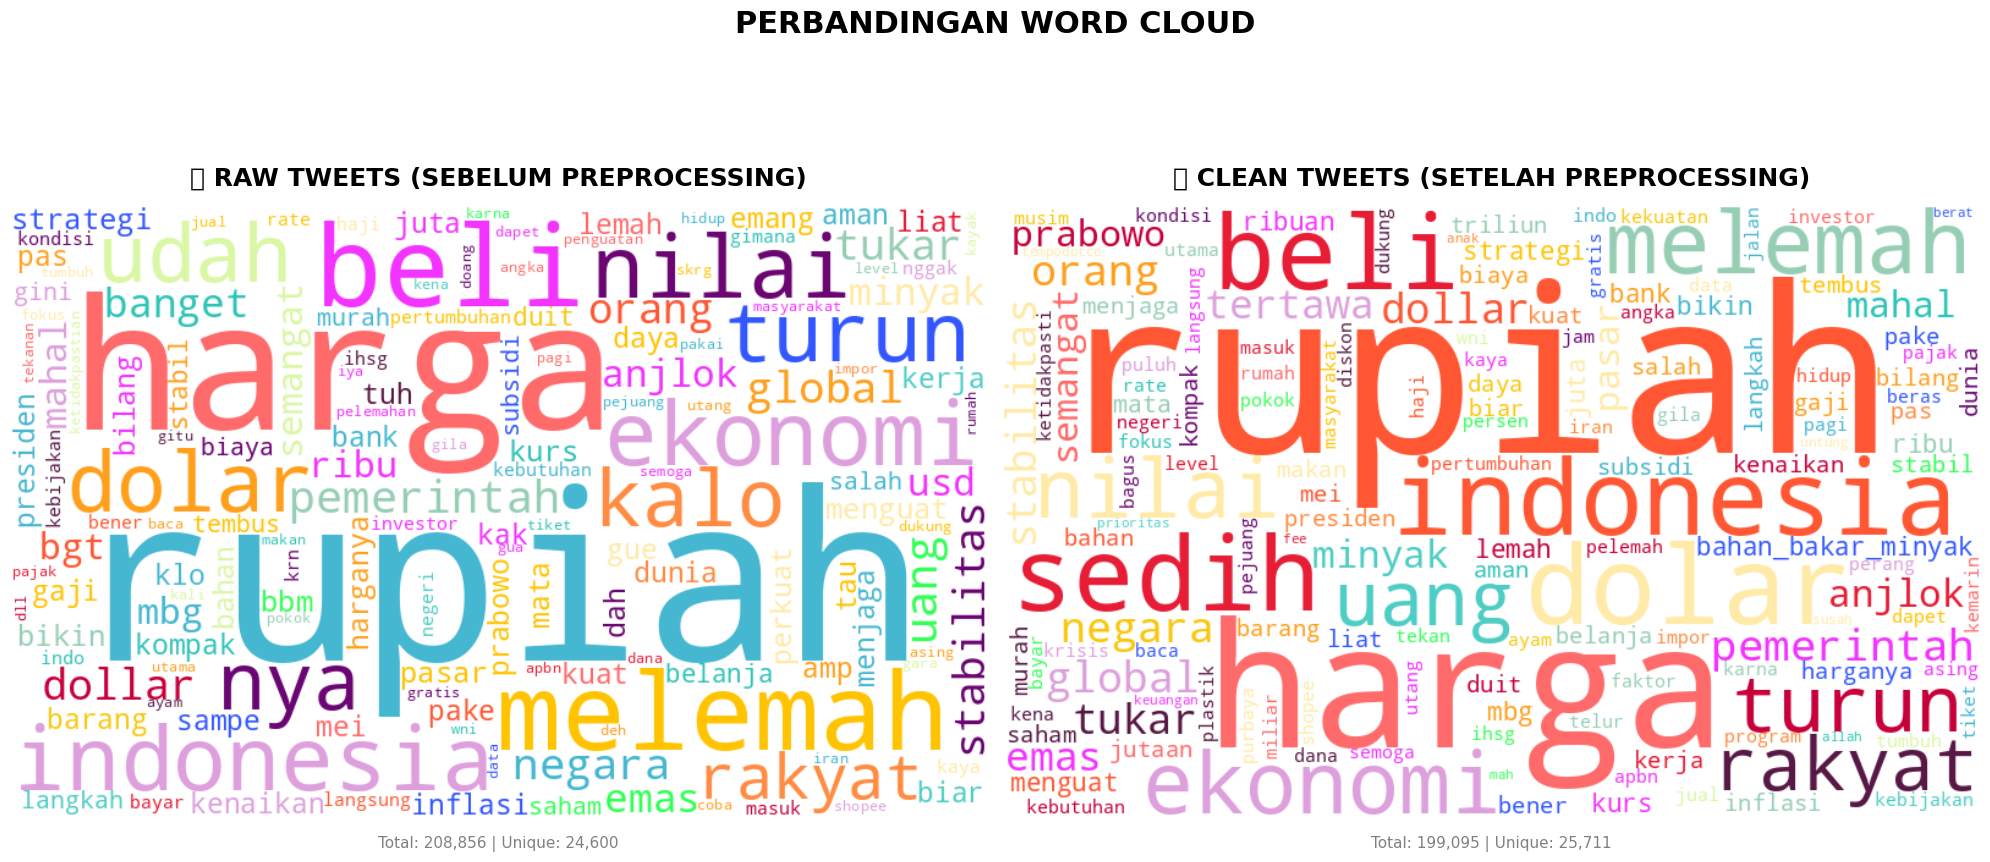


💾 MENYIMPAN GAMBAR KE DRIVE...


/tmp/ipykernel_10262/1763988672.py:219: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.savefig(os.path.join(output_dir, 'wordcloud_comparison.png'),
/tmp/ipykernel_10262/1763988672.py:219: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.savefig(os.path.join(output_dir, 'wordcloud_comparison.png'),


✓ Tersimpan: /content/drive/MyDrive/Penelitian_@/progress/wordcloud_comparison.png
✓ Tersimpan: /content/drive/MyDrive/Penelitian_@/progress/wordcloud_raw.png
✓ Tersimpan: /content/drive/MyDrive/Penelitian_@/progress/wordcloud_clean.png
✓ Tersimpan: top100_words_raw.csv & top100_words_clean.csv

✅ SELESAI!

📁 Semua file tersimpan di: /content/drive/MyDrive/Penelitian_@/progress
   ├── wordcloud_comparison.png  (tampilan berdampingan)
   ├── wordcloud_raw.png         (RAW saja)
   ├── wordcloud_clean.png       (CLEAN saja)
   ├── top100_words_raw.csv
   └── top100_words_clean.csv

📊 STATISTIK:
   RAW   : 208,856 token | 24,600 unique
   CLEAN : 199,095 token | 25,711 unique
   Reduksi: 4.7% noise terhapus

🎨 Warna: WARNA WARNI (random cerah)


In [ ]:
# =========================================================
# WORD CLOUD ANALISIS: RAW vs CLEAN (PREPROCESSED)
# TAMPIL DI COLAB + SIMPAN KE DRIVE
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import re
import os
import random

# =========================================================
# 1. KONFIGURASI
# =========================================================

input_file = '/content/drive/MyDrive/Penelitian_@/progress/hasil_preprocessing_final.csv'
output_dir = '/content/drive/MyDrive/Penelitian_@/progress'

# Palet warna cerah
WARNA_CERAH = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
    '#DDA0DD', '#FF8C42', '#6A0572', '#F9C80E', '#E71D36',
    '#FF9F1C', '#2EC4B6', '#FFC300', '#DAF7A6', '#581845',
    '#C70039', '#FF5733', '#33FF57', '#3357FF', '#F333FF'
]

def warna_random(word=None, font_size=None, position=None,
                 orientation=None, font_path=None, random_state=None):
    """Fungsi untuk warna random cerah"""
    return random.choice(WARNA_CERAH)

# =========================================================
# 2. STOPWORDS
# =========================================================

stopwords_additional = {
    'the', 'a', 'an', 'is', 'are', 'was', 'were', 'to', 'of', 'for', 'in',
    'on', 'at', 'by', 'with', 'without', 'and', 'or', 'but', 'so', 'if',
    'then', 'else', 'when', 'where', 'which', 'who', 'whom', 'this', 'that',
    'these', 'those', 'it', 'they', 'we', 'you', 'he', 'she', 'they', 'them',
    'saya', 'anda', 'kami', 'mereka', 'kita', 'kamu', 'dia', 'beliau'
}

try:
    from nltk.corpus import stopwords
    base_stopwords = set(stopwords.words('indonesian'))
    all_stopwords = base_stopwords | stopwords_additional
    print(f"✓ Stopwords loaded: {len(all_stopwords)} words")
except:
    all_stopwords = stopwords_additional
    print(f"✓ Stopwords manual: {len(all_stopwords)} words")

# =========================================================
# 3. BACA DATA
# =========================================================

print("\n📂 MEMBACA DATA...")
df = pd.read_csv(input_file)
print(f"✓ Data loaded: {len(df):,} rows")

# Cek kolom preprocessing
preprocess_col = None
for col in df.columns:
    if 'preprocessing' in col.lower() or 'hasil' in col.lower():
        preprocess_col = col
        break
if preprocess_col is None:
    preprocess_col = df.columns[1]

print(f"✓ Menggunakan kolom: '{preprocess_col}'")

# =========================================================
# 4. PROSES CLEAN TEXT
# =========================================================

print("\n🔄 MEMPROSES CLEAN TEXT...")

def proses_clean(text):
    if not isinstance(text, str) or text == 'empty':
        return []
    hasil = []
    for token in text.split():
        if len(token) < 2:
            continue
        if token.endswith('_negated'):
            token = token.replace('_negated', '')
        if token in all_stopwords or len(token) < 3:
            continue
        hasil.append(token)
    return hasil

all_clean = []
for _, row in df.iterrows():
    all_clean.extend(proses_clean(row[preprocess_col]))

clean_freq = Counter(all_clean)
print(f"✓ Clean: {len(all_clean):,} token | {len(clean_freq):,} unique")

# =========================================================
# 5. PROSES RAW TEXT
# =========================================================

print("\n🔄 MEMPROSES RAW TEXT...")

def proses_raw(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    hasil = []
    for token in text.split():
        if len(token) < 3 or token in all_stopwords:
            continue
        hasil.append(token)
    return hasil

all_raw = []
for _, row in df.iterrows():
    raw_text = row.get('raw_text', row[preprocess_col])
    all_raw.extend(proses_raw(raw_text))

raw_freq = Counter(all_raw)
print(f"✓ Raw: {len(all_raw):,} token | {len(raw_freq):,} unique")

# =========================================================
# 6. TOP 20 KATA
# =========================================================

print("\n" + "="*60)
print("📊 TOP 20 KATA - RAW TEXT")
print("="*60)
for i, (w, f) in enumerate(raw_freq.most_common(20), 1):
    print(f"{i:2}. '{w}': {f:6,}x")

print("\n" + "="*60)
print("📊 TOP 20 KATA - CLEAN TEXT")
print("="*60)
for i, (w, f) in enumerate(clean_freq.most_common(20), 1):
    print(f"{i:2}. '{w}': {f:6,}x")

# =========================================================
# 7. BUAT WORD CLOUD
# =========================================================

print("\n🎨 MEMBUAT WORD CLOUD...")

# Filter untuk RAW
raw_filtered = {w: f for w, f in raw_freq.most_common(200)
                if w not in ['yg', 'org', 'gak', 'udh', 'aja', 'nih', 'sih']}

# Filter untuk CLEAN
clean_filtered = {w: f for w, f in clean_freq.most_common(200)}

# Buat word cloud RAW
raw_wc = WordCloud(
    width=800, height=500,
    background_color='white',
    max_words=150,
    color_func=warna_random,
    random_state=42,
    collocations=False
).generate_from_frequencies(raw_filtered)

# Buat word cloud CLEAN
clean_wc = WordCloud(
    width=800, height=500,
    background_color='white',
    max_words=150,
    color_func=warna_random,
    random_state=42,
    collocations=False
).generate_from_frequencies(clean_filtered)

# =========================================================
# 8. TAMPILKAN BERSELAHAN DI COLAB
# =========================================================

print("\n📊 MENAMPILKAN WORD CLOUD...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# RAW (Kiri)
ax1.imshow(raw_wc, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('📝 RAW TWEETS (SEBELUM PREPROCESSING)',
              fontsize=18, fontweight='bold', pad=15)
ax1.text(0.5, -0.05, f'Total: {len(all_raw):,} | Unique: {len(raw_freq):,}',
         transform=ax1.transAxes, ha='center', fontsize=11, color='gray')

# CLEAN (Kanan)
ax2.imshow(clean_wc, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('✨ CLEAN TWEETS (SETELAH PREPROCESSING)',
              fontsize=18, fontweight='bold', pad=15)
ax2.text(0.5, -0.05, f'Total: {len(all_clean):,} | Unique: {len(clean_freq):,}',
         transform=ax2.transAxes, ha='center', fontsize=11, color='gray')

# Judul utama
plt.suptitle('PERBANDINGAN WORD CLOUD', fontsize=22, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

# =========================================================
# 9. SIMPAN GAMBAR KE DRIVE
# =========================================================

print("\n💾 MENYIMPAN GAMBAR KE DRIVE...")

# Simpan gambar bersebelahan
fig.savefig(os.path.join(output_dir, 'wordcloud_comparison.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Tersimpan: {output_dir}/wordcloud_comparison.png")

# Simpan gambar RAW saja
fig_raw, ax_raw = plt.subplots(1, 1, figsize=(14, 10))
ax_raw.imshow(raw_wc, interpolation='bilinear')
ax_raw.axis('off')
ax_raw.set_title('WORD CLOUD: RAW TWEETS', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'wordcloud_raw.png'), dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Tersimpan: {output_dir}/wordcloud_raw.png")

# Simpan gambar CLEAN saja
fig_clean, ax_clean = plt.subplots(1, 1, figsize=(14, 10))
ax_clean.imshow(clean_wc, interpolation='bilinear')
ax_clean.axis('off')
ax_clean.set_title('WORD CLOUD: CLEAN TWEETS', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'wordcloud_clean.png'), dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Tersimpan: {output_dir}/wordcloud_clean.png")

# =========================================================
# 10. SIMPAN TOP 100 KATA
# =========================================================

pd.DataFrame(raw_freq.most_common(100), columns=['Kata', 'Frekuensi']).to_csv(
    os.path.join(output_dir, 'top100_words_raw.csv'), index=False)
pd.DataFrame(clean_freq.most_common(100), columns=['Kata', 'Frekuensi']).to_csv(
    os.path.join(output_dir, 'top100_words_clean.csv'), index=False)
print(f"✓ Tersimpan: top100_words_raw.csv & top100_words_clean.csv")

# =========================================================
# 11. HASIL AKHIR
# =========================================================

print("\n" + "="*60)
print("✅ SELESAI!")
print("="*60)
print(f"\n📁 Semua file tersimpan di: {output_dir}")
print("   ├── wordcloud_comparison.png  (tampilan berdampingan)")
print("   ├── wordcloud_raw.png         (RAW saja)")
print("   ├── wordcloud_clean.png       (CLEAN saja)")
print("   ├── top100_words_raw.csv")
print("   └── top100_words_clean.csv")

print(f"\n📊 STATISTIK:")
print(f"   RAW   : {len(all_raw):,} token | {len(raw_freq):,} unique")
print(f"   CLEAN : {len(all_clean):,} token | {len(clean_freq):,} unique")
print(f"   Reduksi: {(1 - len(all_clean)/len(all_raw))*100:.1f}% noise terhapus")

print("\n🎨 Warna: WARNA WARNI (random cerah)")
print("="*60)